In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, filters, feature
import tensorflow as tf
from tensorflow.keras import layers, models

In [21]:
# function to show images
def show(img, cmap=None, title=None):
    plt.imshow(img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

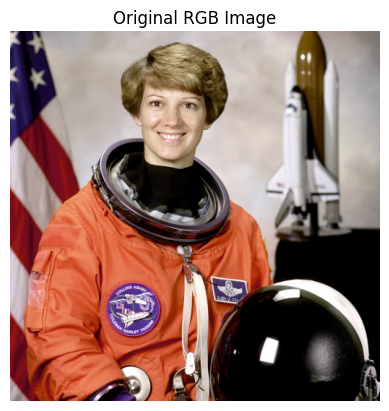

In [22]:
img = data.astronaut()
show(img, title="Original RGB Image")

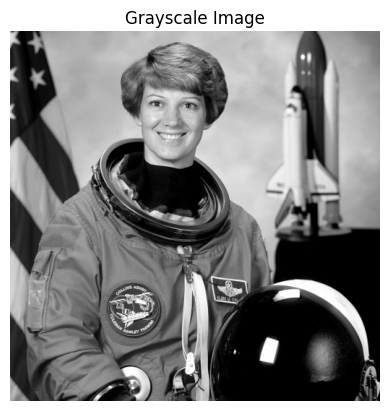

In [23]:
# converting to grayscale
gray = color.rgb2gray(img)
show(gray, cmap="gray", title="Grayscale Image")

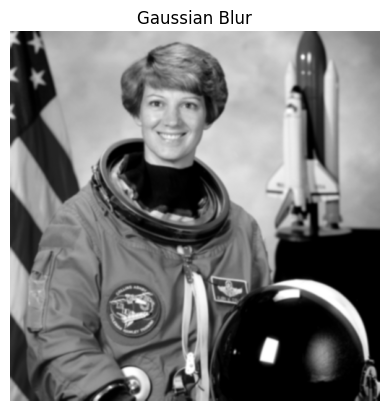

In [24]:
# blurring image
blur = cv2.GaussianBlur(gray, (7,7), 1)
show(blur, cmap="gray", title="Gaussian Blur")

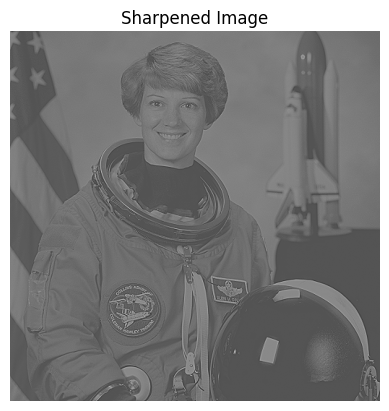

In [25]:
# sharpening image
kernel = np.array([[0, -1, 0],
                   [-1, 5,-1],
                   [0, -1, 0]])
sharpen = cv2.filter2D(gray, -1, kernel)
show(sharpen, cmap="gray", title="Sharpened Image")

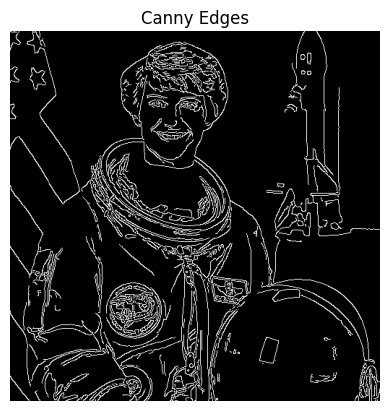

In [26]:
# edge detection using Canny edge detector
edges = cv2.Canny((gray*255).astype(np.uint8), 100, 200)
show(edges, cmap="gray", title="Canny Edges")

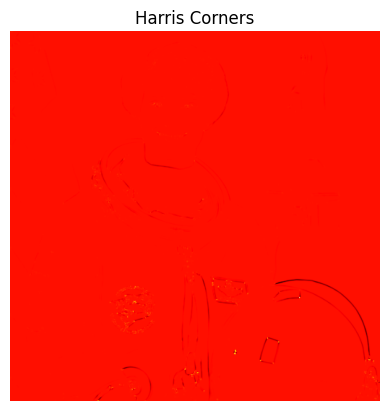

In [27]:
# corner detection using Harris corner detector
harris = cv2.cornerHarris((gray*255).astype(np.uint8), 2, 3, 0.04)
show(harris, cmap="hot", title="Harris Corners")

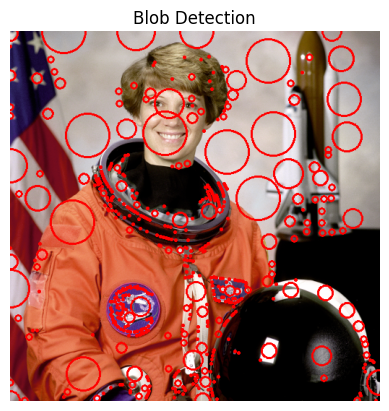

In [28]:
# blob detection
blobs = feature.blob_log(gray, max_sigma=30, threshold=0.1)
blobs_img = img.copy()
for y, x, r in blobs:
    cv2.circle(blobs_img, (int(x), int(y)), int(r), (255,0,0), 2)
show(blobs_img, title="Blob Detection")

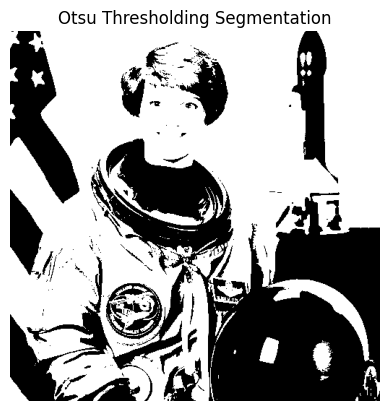

In [29]:
# image segmentation
thresh_val = filters.threshold_otsu(gray)
seg = gray > thresh_val
show(seg, cmap="gray", title="Otsu Thresholding Segmentation")

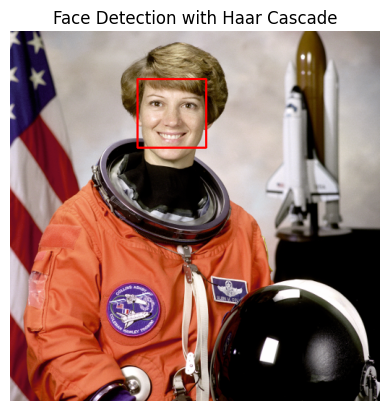

In [30]:
# Object detection using Haar cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
faces = face_cascade.detectMultiScale((gray*255).astype(np.uint8), 1.3, 5)
img_faces = img.copy()
for (x,y,w,h) in faces:
    cv2.rectangle(img_faces,(x,y),(x+w,y+h),(255,0,0),2)
show(img_faces, title="Face Detection with Haar Cascade")

#### Deep learning example using MNIST dataset

In [31]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [33]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [32]:
y_train[0]

np.uint8(5)

In [14]:
# data preprocessing
# The original MNIST images are stored as (num_samples, 28, 28) arrays. CNNs expect data with a channel dimension.
# For grayscale images, we add a single channel → (28, 28, 1). -1 means “infer the number of samples automatically.”
# The raw MNIST pixel values are integers in the range 0-255. Converting to floats makes them suitable for numerical operations in TF
# / 255.0 normalizes pixel values from [0, 255] → [0, 1]. 
# Normalization improves model training because Smaller, bounded values prevent very large gradients.
# and also because neural networks converge faster when inputs are scaled consistently.
x_train = x_train.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)).astype("float32") / 255.0

In [15]:
# CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/home/lmuyama/anaconda3/envs/nlp_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-22 13:45:20.093744: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-09-22 13:45:20.093777: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-09-22 13:45:20.093781: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: PL1207-PRO.paris.inria.fr
2025-09-

In [16]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
# training model
history = model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9589 - loss: 0.1330 - val_accuracy: 0.9847 - val_loss: 0.0479
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9867 - loss: 0.0434 - val_accuracy: 0.9884 - val_loss: 0.0350
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9904 - loss: 0.0295 - val_accuracy: 0.9894 - val_loss: 0.0315


In [18]:
# evaluating model
# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.9894
